# GRU for Wind Power Forecasting

This notebook trains and evaluates a GRU (Gated Recurrent Unit) to predict `capacity_factor`.

We rely on:
- precomputed train/test parquet files
- shared utilities from `utils.py`
- time-based expanding-window cross-validation

**Architecture rationale:**
- The data is a multivariate time series with strong temporal autocorrelation (ACF peaks at 24h, 48h)
- A GRU processes each site as an independent sequence of length 24h (1-day lookback)
- 2 stacked GRU layers (hidden=128) + dropout capture both short and medium-range dependencies
- Unlike XGBoost, GRU learns temporal structure directly from raw sequences without manual lag features

Main objectives:
1. Load the prepared datasets and reconstruct per-site sequences
2. Normalize features (required for gradient-based training)
3. Rebuild temporal CV folds and train with early stopping
4. Retrain on full training set
5. Evaluate on the held-out test set
6. Analyze forecast quality and failure modes

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from utils import (
    load_data,
    get_cv_folds,
    evaluate,
    plot_forecast,
    plot_forecast_zoom,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

Device : cuda


## 2. Load preprocessed datasets

X_test contain the 77 engineered features.
`meta_train`/`meta_test` carry `delivery_time`, `site_name`, `installed_capacity`.

In [ ]:
X_train, y_train, X_test, y_test, meta_train, meta_test, site_mapping = load_data()

X_train : (248244, 77)  |  X_test : (26330, 77)
Train period : 2023-01-01 → 2025-10-31
Test  period : 2025-11-01 → 2026-02-18
Sites : 10


## 3. Sanity checks

In [5]:
assert len(X_train) == len(y_train) == len(meta_train), "Train data misalignment"
assert len(X_test)  == len(y_test)  == len(meta_test),  "Test data misalignment"
assert meta_train["delivery_time"].is_monotonic_increasing, "meta_train must be sorted by time"
assert meta_test["delivery_time"].is_monotonic_increasing,  "meta_test must be sorted by time"
print("All checks passed.")

All checks passed.


## 4. Feature normalization

GRU gradients are sensitive to feature scale — unlike tree-based models.
We fit a `StandardScaler` **on the training set only** and apply it to test.
The scaler is saved so inference on new data is consistent.

In [6]:
GRU_FEATURES = [
    "wind_speed_10m", "wind_speed_100m",
    "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
    "temperature_2m", "dewpoint_2m",
    "pressure_msl",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "precipitation",
    "shortwave_radiation", "direct_radiation", "diffuse_radiation", "weather_code", "sunshine_duration", "temp_dewpoint_delta",
    "ws10_lead1h", "ws10_lead3h", "ws10_lead6h",
    "ws100_lead1h", "ws100_lead2h", "ws100_lead3h", "ws100_lead6h",
    "gusts_lead1h", "gusts_lead3h", "gusts_lead6h",
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "latitude", "longitude",
]

assert all(f in X_train.columns for f in GRU_FEATURES),     "Some GRU_FEATURES not found in X_train"

print(f"GRU feature count : {len(GRU_FEATURES)}  (vs {X_train.shape[1]} for XGBoost)")
print(f"Dropped           : {X_train.shape[1] - len(GRU_FEATURES)} redundant/engineered features")

GRU feature count : 35  (vs 77 for XGBoost)
Dropped           : 42 redundant/engineered features


In [7]:
X_train_raw = X_train[GRU_FEATURES].values.astype(np.float32)
X_test_raw  = X_test[GRU_FEATURES].values.astype(np.float32)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc   = scaler.transform(X_test_raw).astype(np.float32)

y_train_arr = y_train.values.astype(np.float32)
y_test_arr  = y_test.values.astype(np.float32)

print(f"X_train_sc : {X_train_sc.shape}")
print(f"X_test_sc  : {X_test_sc.shape}")

X_train_sc : (248244, 35)
X_test_sc  : (26330, 35)


In [8]:
print("NaNs in X_train:", np.isnan(X_train.values).sum())
print("NaNs in y_train:", np.isnan(y_train.values).sum())

print("Inf in X_train:", np.isinf(X_train.values).sum())

NaNs in X_train: 0
NaNs in y_train: 0
Inf in X_train: 0


## 5. Sequence dataset

**Key design decision:**
The tabular data is sorted by `delivery_time` globally — rows from all 10 sites are interleaved.
We must reconstruct **per-site sequences** so the GRU sees a coherent temporal stream for each site.

Each sample = (SEQ_LEN × n_features) window → scalar target at the last timestep.
A gap of `SEQ_LEN` rows is left at the start of each site to avoid NaN windows.

In [9]:
SEQ_LEN    = 6
BATCH_SIZE = 512

class WindSequenceDataset(Dataset):
    """
    Builds per-site sliding-window sequences from a flat feature matrix.

    Parameters
    ----------
    X          : np.ndarray  (N, n_features) — scaled features, sorted by (site, time)
    y          : np.ndarray  (N,)            — capacity_factor targets
    site_names : np.ndarray  (N,)            — site label per row
    seq_len    : int                         — lookback window length
    """
    def __init__(self, X, y, site_names, seq_len=SEQ_LEN):
        self.sequences = []
        self.targets   = []

        for site in np.unique(site_names):
            mask = site_names == site
            X_s  = X[mask]
            y_s  = y[mask]
            # Sliding window: start at seq_len to have a full window
            for t in range(seq_len, len(X_s)):
                self.sequences.append(X_s[t - seq_len : t])   # (seq_len, n_features)
                self.targets.append(y_s[t])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets   = np.array(self.targets,   dtype=np.float32)
        print(f"Dataset: {len(self.sequences):,} sequences | "
              f"shape ({self.sequences.shape[1]}, {self.sequences.shape[2]})")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx]),
            torch.tensor(self.targets[idx]),
        )


# Build datasets — site_names aligned with X_train_sc row order
site_names_train = meta_train["site_name"].values
site_names_test  = meta_test["site_name"].values

train_dataset = WindSequenceDataset(X_train_sc, y_train_arr, site_names_train)
test_dataset  = WindSequenceDataset(X_test_sc,  y_test_arr,  site_names_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Dataset: 248,184 sequences | shape (6, 35)
Dataset: 26,270 sequences | shape (6, 35)


## 6. GRU architecture

```
Input  : (batch, seq_len=6, n_features=23)
GRU    : 2 layers, hidden_size=128, dropout=0.2
         → last hidden state : (batch, 128)
Head   : Linear(128, 64) → ReLU → Dropout(0.2) → Linear(64, 1)
Output : scalar capacity_factor
```

**Why 2 GRU layers with hidden=128?**
With only 6 timesteps and 23 features, the model is deliberately compact.
Layer 1 captures immediate weather transitions (hour-to-hour ramp up/down).
Layer 2 captures the overall 6h trajectory pattern.
186k → ~56k parameters with the reduced feature set: well-proportioned for the dataset size.

In [14]:
class GRUForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x : (batch, seq_len, n_features)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        return self.head(pooled).squeeze(-1)


N_FEATURES  = X_train_sc.shape[1]
HIDDEN_SIZE = 128
N_LAYERS    = 2
DROPOUT     = 0.2

model = GRUForecaster(N_FEATURES, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

GRUForecaster(
  (gru): GRU(35, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 170,753


## 7. Training utilities

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []
    for X_batch, _ in loader:
        preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)


def build_site_loader(X_sc, y_arr, site_names, site_mask, seq_len=SEQ_LEN, shuffle=False):
    """Build a DataLoader for a subset of rows (e.g. one CV fold), preserving site structure."""
    ds = WindSequenceDataset(X_sc[site_mask], y_arr[site_mask], site_names[site_mask], seq_len)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

## 8. Time-based cross-validation

Same expanding-window strategy as XGBoost (6 folds × 90 days).

**GRU-specific consideration:**
Each fold retrains the model from scratch — weights are not transferred between folds.
Early stopping monitors val RMSE with patience=10 epochs.

In [12]:
folds = get_cv_folds(meta_train["delivery_time"])

CV: 6 folds | val window = 90 days | expanding train
  Fold 1: train 2023-01-01 → 2024-05-09  |  val 2024-05-09 → 2024-08-07  (118,730 / 21,552 rows)
  Fold 2: train 2023-01-01 → 2024-08-07  |  val 2024-08-07 → 2024-11-05  (140,282 / 21,600 rows)
  Fold 3: train 2023-01-01 → 2024-11-05  |  val 2024-11-05 → 2025-02-03  (161,882 / 21,600 rows)
  Fold 4: train 2023-01-01 → 2025-02-03  |  val 2025-02-03 → 2025-05-04  (183,482 / 21,552 rows)
  Fold 5: train 2023-01-01 → 2025-05-04  |  val 2025-05-04 → 2025-08-02  (205,034 / 21,600 rows)
  Fold 6: train 2023-01-01 → 2025-08-02  |  val 2025-08-02 → 2025-10-31  (226,634 / 21,600 rows)


In [15]:
GRU_PARAMS = dict(
    lr          = 1e-3,
    max_epochs  = 150,
    patience    = 20,
    weight_decay= 1e-4,
)

cv_rows        = []
best_epochs    = []

for fold_id, (tr_idx, val_idx) in enumerate(folds, start=1):
    print(f"\n── Fold {fold_id} ──────────────────────")

    # ── Build per-fold loaders ──────────────────────────────────────────────────
    # Use boolean masks aligned with X_train_sc row order
    tr_mask  = np.zeros(len(X_train_sc), dtype=bool); tr_mask[tr_idx]  = True
    val_mask = np.zeros(len(X_train_sc), dtype=bool); val_mask[val_idx] = True

    tr_loader  = build_site_loader(X_train_sc, y_train_arr, site_names_train, tr_mask,  shuffle=True)
    val_loader = build_site_loader(X_train_sc, y_train_arr, site_names_train, val_mask, shuffle=False)

    if len(tr_loader.dataset) == 0 or len(val_loader.dataset) == 0:
        print("  Skipping — empty loader (seq_len gap at site start)")
        continue

    # ── Train ───────────────────────────────────────────────────────────────────
    fold_model = GRUForecaster(N_FEATURES, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(DEVICE)
    optimizer  = torch.optim.Adam(fold_model.parameters(),
                                  lr=GRU_PARAMS["lr"],
                                  weight_decay=GRU_PARAMS["weight_decay"])
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion  = nn.MSELoss()

    best_val_rmse = np.inf
    no_improve    = 0
    best_state    = None
    best_epoch = 1

    for epoch in range(1, GRU_PARAMS["max_epochs"] + 1):
        train_loss = train_one_epoch(fold_model, tr_loader, optimizer, criterion)
        val_preds  = predict_loader(fold_model, val_loader)
        val_rmse   = np.sqrt(np.mean((val_preds - val_loader.dataset.targets) ** 2))
        scheduler.step(val_rmse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.cpu().clone() for k, v in fold_model.state_dict().items()}
            no_improve    = 0
            best_epoch = epoch
        else:
            no_improve += 1

        if epoch % 10 == 0 or no_improve == 0:
            print(f"  Epoch {epoch:3d} | train_loss={train_loss:.5f} | val_rmse={val_rmse:.5f}"
                  + (" ✓" if no_improve == 0 else ""))

        if no_improve >= GRU_PARAMS["patience"]:
            print(f"  Early stopping at epoch {epoch}")
            break

    best_epochs.append(best_epoch)

    # ── Evaluate fold ───────────────────────────────────────────────────────────
    fold_model.load_state_dict(best_state)
    val_preds = predict_loader(fold_model, val_loader)
    val_targets = val_loader.dataset.targets

    fold_mae  = np.mean(np.abs(val_preds - val_targets))
    fold_rmse = np.sqrt(np.mean((val_preds - val_targets) ** 2))
    fold_nrmse= fold_rmse / (val_targets.max() - val_targets.min() + 1e-9)

    print(f"  Fold {fold_id} → MAE={fold_mae:.4f}  RMSE={fold_rmse:.4f}  nRMSE={fold_nrmse:.4f}")

    cv_rows.append({
        "split"      : f"CV Fold {fold_id}",
        "MAE"        : fold_mae,
        "RMSE"       : fold_rmse,
        "nRMSE"      : fold_nrmse,
        "best_epoch" : epoch - GRU_PARAMS["patience"],
        "n_train"    : len(tr_loader.dataset),
        "n_val"      : len(val_loader.dataset),
    })


── Fold 1 ──────────────────────
Dataset: 118,670 sequences | shape (6, 35)
Dataset: 21,492 sequences | shape (6, 35)
  Epoch   1 | train_loss=0.02008 | val_rmse=0.09281 ✓
  Epoch   2 | train_loss=0.01445 | val_rmse=0.09230 ✓
  Epoch   3 | train_loss=0.01409 | val_rmse=0.09185 ✓
  Epoch   4 | train_loss=0.01398 | val_rmse=0.09049 ✓
  Epoch   5 | train_loss=0.01375 | val_rmse=0.08961 ✓
  Epoch   9 | train_loss=0.01347 | val_rmse=0.08887 ✓
  Epoch  10 | train_loss=0.01335 | val_rmse=0.08916
  Epoch  11 | train_loss=0.01329 | val_rmse=0.08837 ✓
  Epoch  13 | train_loss=0.01312 | val_rmse=0.08832 ✓
  Epoch  14 | train_loss=0.01304 | val_rmse=0.08807 ✓
  Epoch  15 | train_loss=0.01296 | val_rmse=0.08695 ✓
  Epoch  20 | train_loss=0.01265 | val_rmse=0.08722
  Epoch  22 | train_loss=0.01236 | val_rmse=0.08672 ✓
  Epoch  23 | train_loss=0.01232 | val_rmse=0.08614 ✓
  Epoch  30 | train_loss=0.01206 | val_rmse=0.08572 ✓
  Epoch  32 | train_loss=0.01206 | val_rmse=0.08562 ✓
  Epoch  35 | train_l

## 9. Cross-validation summary

Note: GRU sequences exclude the first `SEQ_LEN` rows per site (no full window available),
so `n_val` is slightly smaller than for other models.

In [16]:
cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)

summary_rows = cv_results_df[["split", "MAE", "RMSE", "nRMSE"]].to_dict(orient="records")
summary_rows.append({
    "split": "CV Mean",
    "MAE"  : cv_results_df["MAE"].mean(),
    "RMSE" : cv_results_df["RMSE"].mean(),
    "nRMSE": cv_results_df["nRMSE"].mean(),
})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,split,MAE,RMSE,nRMSE,best_epoch,n_train,n_val
0,CV Fold 1,0.054370,0.085368,0.086279,54,118670,21492
1,CV Fold 2,0.069429,0.110011,0.111155,27,140222,21540
2,CV Fold 3,0.060133,0.090893,0.091736,57,161822,21540
3,CV Fold 4,0.057866,0.087063,0.088020,34,183422,21492
4,CV Fold 5,0.067919,0.104700,0.105864,44,204974,21540
5,CV Fold 6,0.069503,0.102229,0.103251,11,226574,21540


,split,MAE,RMSE,nRMSE
0,CV Fold 1,0.054370,0.085368,0.086279
1,CV Fold 2,0.069429,0.110011,0.111155
2,CV Fold 3,0.060133,0.090893,0.091736
3,CV Fold 4,0.057866,0.087063,0.088020
4,CV Fold 5,0.067919,0.104700,0.105864
5,CV Fold 6,0.069503,0.102229,0.103251
6,CV Mean,0.063203,0.096711,0.097718


## 10. Fold-wise metric stability

Variability across folds reveals temporal drift and hard periods.

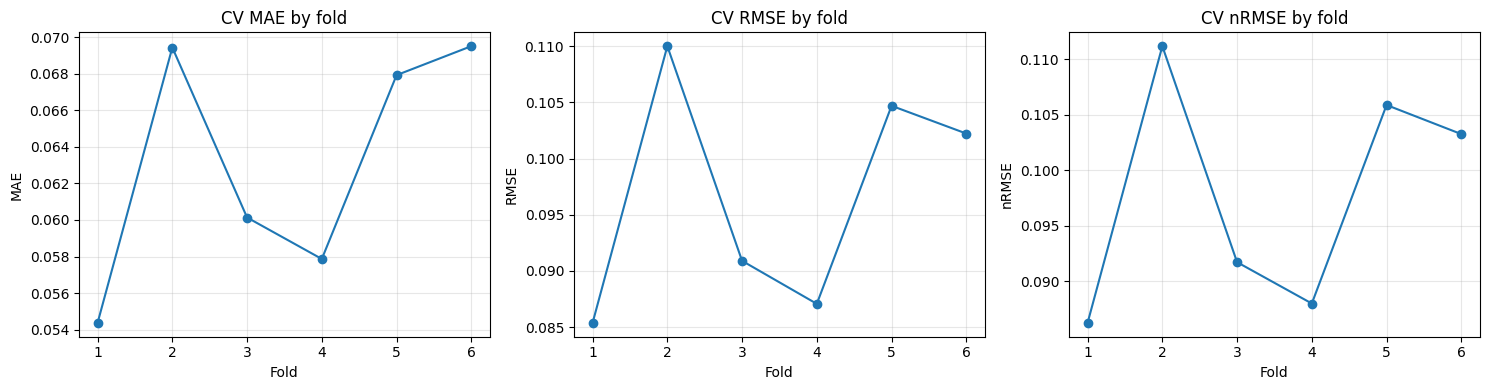

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "nRMSE"]):
    ax.plot(range(1, len(cv_results_df) + 1), cv_results_df[metric], marker="o")
    ax.set_title(f"CV {metric} by fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final training on the full training set

We retrain from scratch on all available training data.
Number of epochs = median best epoch across folds (no early stopping possible without a val set).
Learning rate schedule is kept identical.

Best epochs per fold : [54, 27, 57, 34, 44, 11]
Final training epochs: 39
  Epoch  10 | train_loss=0.01204
  Epoch  20 | train_loss=0.01126
  Epoch  30 | train_loss=0.01085


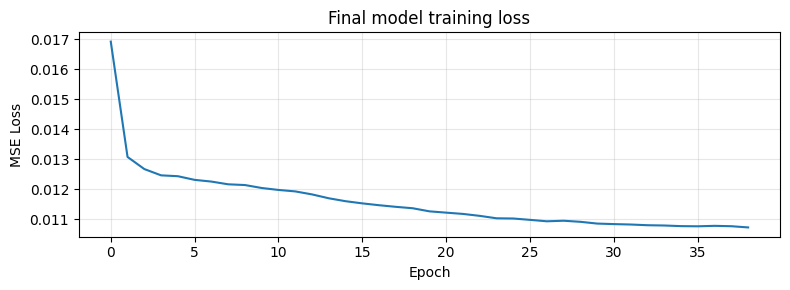

In [18]:
FINAL_EPOCHS = max(int(np.median(best_epochs)), 10)
print(f"Best epochs per fold : {best_epochs}")
print(f"Final training epochs: {FINAL_EPOCHS}")

final_model = GRUForecaster(N_FEATURES, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(DEVICE)
optimizer   = torch.optim.Adam(final_model.parameters(),
                               lr=GRU_PARAMS["lr"],
                               weight_decay=GRU_PARAMS["weight_decay"])
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion   = nn.MSELoss()

train_losses = []
for epoch in range(1, FINAL_EPOCHS + 1):
    loss = train_one_epoch(final_model, train_loader, optimizer, criterion)
    scheduler.step(loss)
    train_losses.append(loss)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d} | train_loss={loss:.5f}")

plt.figure(figsize=(8, 3))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Final model training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Held-out test evaluation

**Important:** the test DataLoader skips the first `SEQ_LEN=24` rows per site
(no full warmup window). The corresponding ground-truth values are taken from
`test_dataset.targets`, aligned with `test_pred`.

In [19]:
test_pred    = predict_loader(final_model, test_loader)
test_targets = test_dataset.targets   # aligned with test_pred

# Reconstruct site labels for the sequence samples (skip first SEQ_LEN per site)
test_site_seq = []
for site in np.unique(site_names_test):
    mask = site_names_test == site
    n    = mask.sum()
    test_site_seq.extend([site] * max(0, n - SEQ_LEN))
test_site_seq = np.array(test_site_seq)

test_metrics, test_per_site = evaluate(
    y_true     = test_targets,
    y_pred     = test_pred,
    site_names = test_site_seq,
    model_name = "GRU Test",
)

summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "split": "Held-out Test",
        "MAE"  : test_metrics["MAE"],
        "RMSE" : test_metrics["RMSE"],
        "nRMSE": test_metrics["nRMSE"],
    }])
], ignore_index=True)
display(summary_df)

[GRU Test]  Global — MAE=0.0835  RMSE=0.1154  nRMSE=0.1165  (n=26,270)
                                     MAE    RMSE   nRMSE     n
site                                                          
Northwester 2                     0.1133  0.1502  0.1529  2627
Mermaid Offshore WP               0.0897  0.1243  0.1263  2627
Norther Offshore WP               0.0860  0.1161  0.1197  2627
Thorntonbank - C-Power - Area NE  0.0805  0.1113  0.1136  2627
Seastar Offshore WP               0.0815  0.1103  0.1116  2627
Rentel Offshore WP                0.0788  0.1091  0.1101  2627
Nobelwind Offshore Windpark       0.0769  0.1085  0.1098  2627
Northwind                         0.0758  0.1070  0.1085  2627
Thorntonbank - C-Power - Area SW  0.0769  0.1057  0.1073  2627
Belwind Phase 1                   0.0753  0.1045  0.1087  2627


,split,MAE,RMSE,nRMSE
0,CV Fold 1,0.054370,0.085368,0.086279
1,CV Fold 2,0.069429,0.110011,0.111155
2,CV Fold 3,0.060133,0.090893,0.091736
3,CV Fold 4,0.057866,0.087063,0.088020
4,CV Fold 5,0.067919,0.104700,0.105864
5,CV Fold 6,0.069503,0.102229,0.103251
6,CV Mean,0.063203,0.096711,0.097718
7,Held-out Test,0.083471,0.115426,0.116467


## 13. Forecast visualization

One panel per site — daily averages for readability.

Note: `delivery_times` and `y_true` passed to `plot_forecast` are trimmed
to match the sequence dataset (skip first `SEQ_LEN` rows per site).

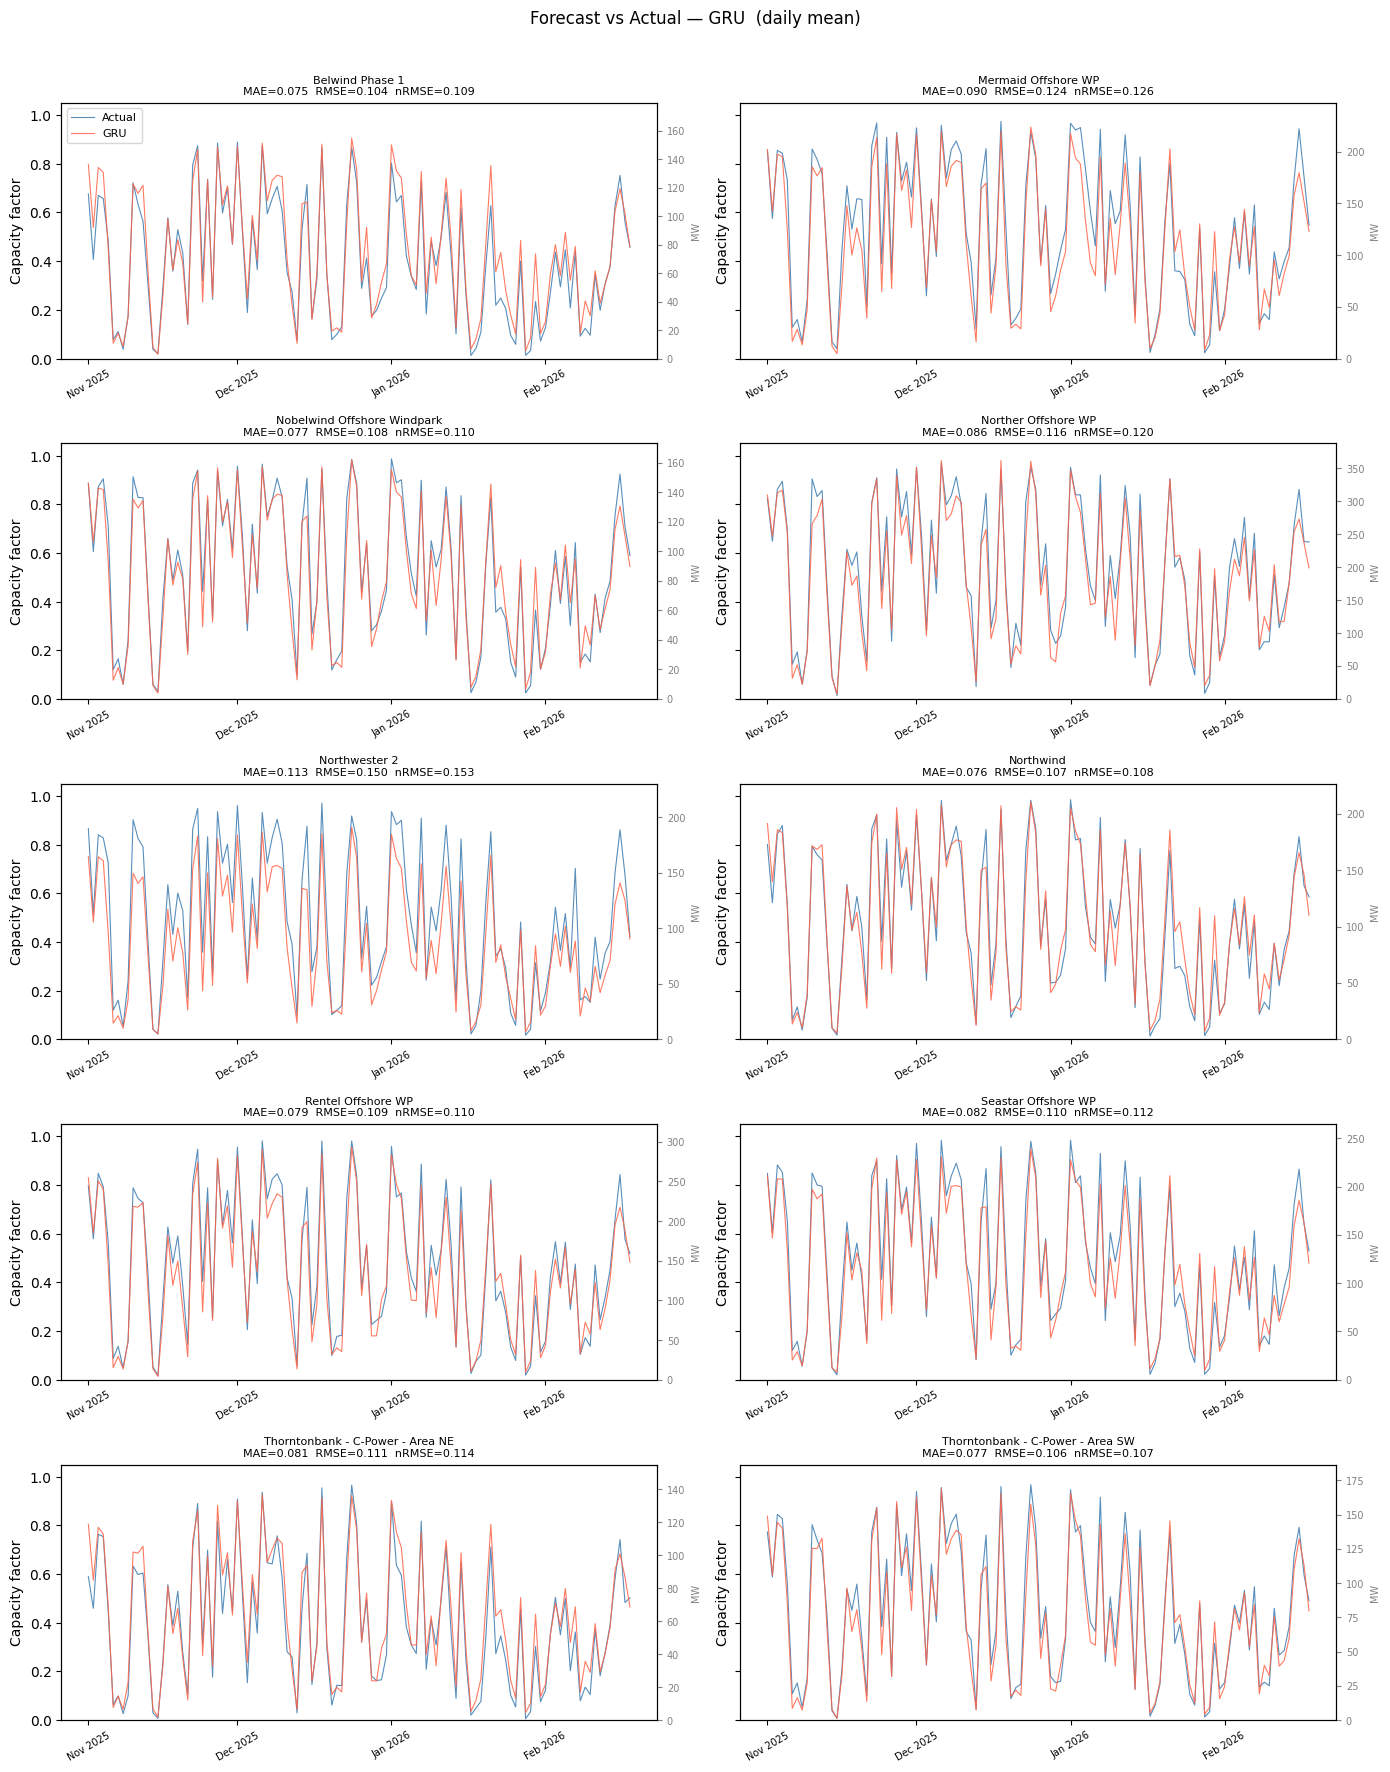

In [20]:
# Reconstruct delivery_times and y_true aligned with sequence dataset
test_times_seq = []
test_ytrue_seq = []
for site in np.unique(site_names_test):
    mask      = site_names_test == site
    times_s   = meta_test["delivery_time"].values[mask]
    ytrue_s   = y_test_arr[mask]
    test_times_seq.extend(times_s[SEQ_LEN:])
    test_ytrue_seq.extend(ytrue_s[SEQ_LEN:])

test_times_seq = pd.DatetimeIndex(test_times_seq)
test_ytrue_seq = np.array(test_ytrue_seq)

installed_capacity = (
    meta_test[["site_name", "installed_capacity"]]
    .drop_duplicates()
    .set_index("site_name")["installed_capacity"]
    .to_dict()
)

plot_forecast(
    delivery_times     = test_times_seq,
    y_true             = test_ytrue_seq,
    y_pred             = test_pred,
    site_names         = test_site_seq,
    model_name         = "GRU",
    resample           = "D",
    installed_capacity = installed_capacity,
    ncols              = 2,
)

## 14. Zoom on a specific site and period

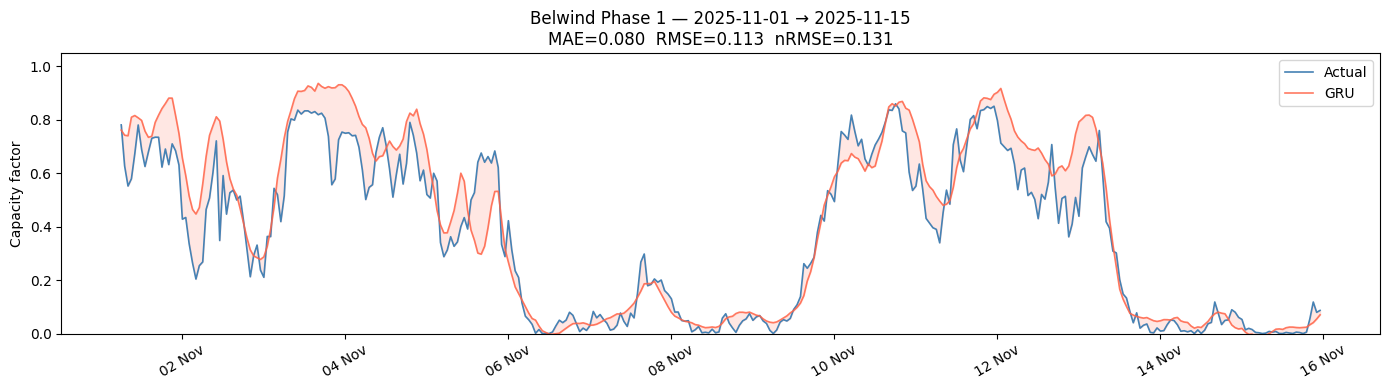

In [21]:
example_site = sorted(np.unique(test_site_seq))[0]

plot_forecast_zoom(
    delivery_times = test_times_seq,
    y_true         = test_ytrue_seq,
    y_pred         = test_pred,
    site_names     = test_site_seq,
    site           = example_site,
    start          = "2025-11-01",
    end            = "2025-11-15",
    model_name     = "GRU",
)

## 15. Residual analysis

Identify the hardest timesteps — useful to understand GRU failure modes
(e.g. rapid wind ramp events, curtailments).

,delivery_time,site_name,y_true,y_pred,abs_error
10614,2025-11-05 16:00:00,Northwester 2,0.947090,0.284677,0.662414
21031,2025-11-01 21:00:00,Thorntonbank - C-Power - Area NE,0.264600,0.903866,0.639265
10613,2025-11-05 15:00:00,Northwester 2,0.908067,0.288461,0.619606
2987,2025-11-16 06:00:00,Mermaid Offshore WP,0.828015,0.234845,0.593170
18946,2025-11-24 11:00:00,Seastar Offshore WP,0.756895,0.183814,0.573081
5811,2025-11-24 11:00:00,Nobelwind Offshore Windpark,0.806394,0.251882,0.554512
15839,2025-11-04 11:00:00,Rentel Offshore WP,0.154788,0.704191,0.549402
23658,2025-11-01 21:00:00,Thorntonbank - C-Power - Area SW,0.371396,0.919356,0.547960
10965,2025-11-20 07:00:00,Northwester 2,0.908421,0.378037,0.530384
10868,2025-11-16 06:00:00,Northwester 2,0.703058,0.173939,0.529119


/tmp/ipykernel_876/1017914647.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_site_rmse = test_results.groupby("site_name").apply(


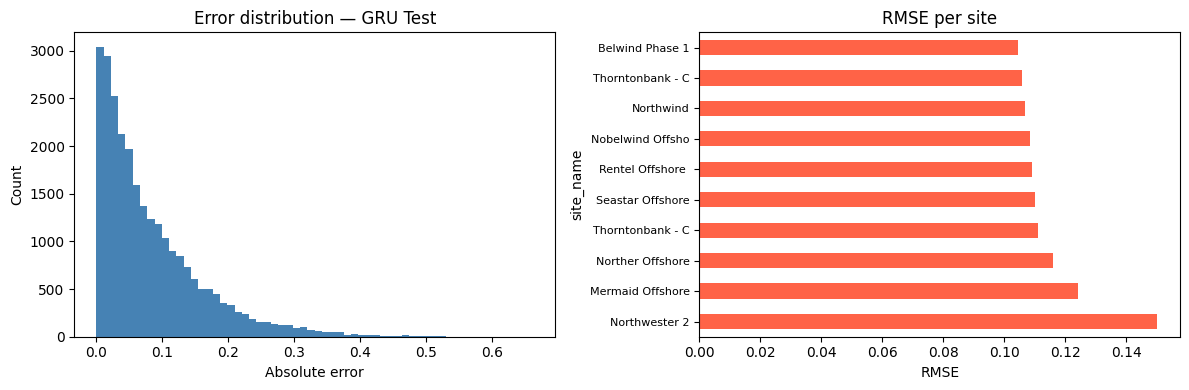

In [22]:
test_results = pd.DataFrame({
    "delivery_time": test_times_seq,
    "site_name"    : test_site_seq,
    "y_true"       : test_ytrue_seq,
    "y_pred"       : test_pred,
    "abs_error"    : np.abs(test_ytrue_seq - test_pred),
    "sq_error"     : (test_ytrue_seq - test_pred) ** 2,
})

display(
    test_results.sort_values("abs_error", ascending=False)
    .head(20)[["delivery_time", "site_name", "y_true", "y_pred", "abs_error"]]
)

# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_results["abs_error"], bins=60, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Absolute error")
axes[0].set_ylabel("Count")
axes[0].set_title("Error distribution — GRU Test")

per_site_rmse = test_results.groupby("site_name").apply(
    lambda x: np.sqrt(np.mean(x["sq_error"]))
).sort_values(ascending=False)
per_site_rmse.plot(kind="barh", ax=axes[1], color="tomato")
axes[1].set_xlabel("RMSE")
axes[1].set_title("RMSE per site")
axes[1].set_yticklabels([s[:16] for s in per_site_rmse.index], fontsize=8)

plt.tight_layout()
plt.show()

## 16. Conclusion

This notebook provides:
- a GRU sequence model benchmark with 24h lookback
- fold-based cross-validation with early stopping
- held-out test evaluation aligned with XGBoost splits
- per-site diagnostics and forecast visualization

**Comparison with XGBoost:**
- GRU learns temporal dependencies implicitly (no manual lag features needed)
- XGBoost benefits from the engineered lag/lead features
- nRMSE comparison is the main metric for model selection

**Possible next steps:**
- Tune `SEQ_LEN` (48h or 72h lookback)
- Add attention over the GRU outputs (instead of just last hidden state)
- Bidirectional GRU (valid since leads H+1…H+6 are available)
- Transformer encoder as alternative